In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

In [ ]:
url="https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"



In [ ]:
df = pd.read_csv(url)

In [ ]:
print("====DATASET DOWNLOADED SUCCESFULLY====")
print(df.head())
print("\nmissing value count :", df.isnull().sum())

====DATASET DOWNLOADED SUCCESFULLY====
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

missing value count : longitude    

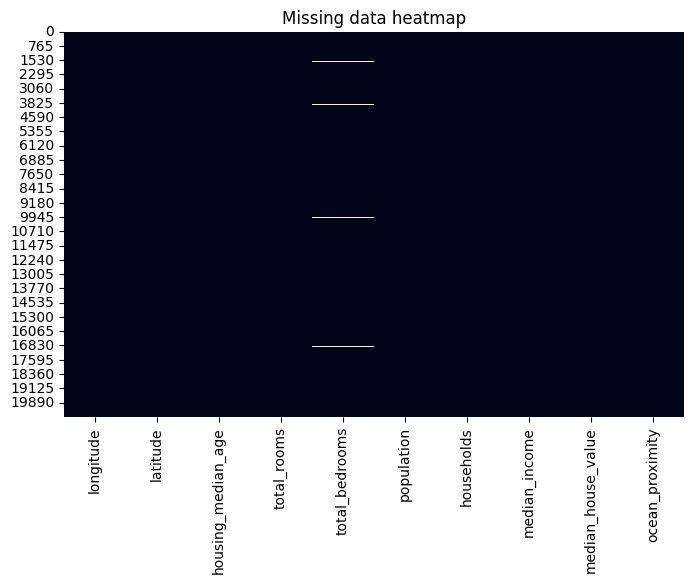

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualizing misssing data

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing data heatmap")
plt.show()

In [ ]:
#drop missing data

df_drop_rows=df.dropna()
df_drop_cols=df.dropna(axis=1)

print("\n After drooping rows :",df_drop_rows.shape)
print("\after drooping cols :", df_drop_cols.shape)



 After drooping rows : (20433, 10)
fter drooping cols : (20640, 9)


In [ ]:
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
#fill with constant

df_const=df.copy()
df_const['total_bedrooms']=df_const['total_bedrooms'].fillna(0)

In [ ]:
#fill with mean/median/mode

df_mean=df.copy()
df_mean['total_bedrooms']=df_mean['total_bedrooms'].fillna(df_mean['total_bedrooms'].mean())

df_median=df.copy()
df_median['total_bedrooms']=df_median['total_bedrooms'].fillna(df_median['total_bedrooms'].median())

df_mode=df.copy()
df_mode['ocean_proximity']=df_mode['ocean_proximity'].fillna(df_mode['ocean_proximity'].mode()[0])

In [ ]:
df_ffill=df.fillna(method='ffill')
df_bfill=df.fillna(method='bfill')

/tmp/ipython-input-1421829411.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill=df.fillna(method='ffill')
/tmp/ipython-input-1421829411.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill=df.fillna(method='bfill')


In [ ]:
#using imputerts

simple_imp=SimpleImputer(strategy='median')
df_simple=df.copy()
df_simple['total_bedrooms']=simple_imp.fit_transform(df_simple[['total_bedrooms']])


In [ ]:
#using KNNImputer
df_kNN=df.copy()
numeric_df=df_kNN.select_dtypes(include=[np.number])
knn_imp=KNNImputer(n_neighbors=5)
knn_result=knn_imp.fit_transform(numeric_df)
df_kNN[numeric_df.columns]=knn_result

print("---\n KNN Imputed Result---")
print(df_kNN.head())

---
 KNN Imputed Result---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


**SCIKIT LEARN -- SKLEARN**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv("/content/diabetes (1).csv")

In [ ]:
#split features and target
x=df.drop("Outcome", axis=1)
y=df["Outcome"]

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#feature scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#Logistic regression
model=LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#predictions
y_pred=model.predict(X_test)

In [ ]:
#evaluation
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [ ]:
#IQR method for outlier detection
#statistical method used to detect outliers
#IQR = Q3-Q1

In [ ]:
#lB=Q1-(1.5*IQR)=outlier

In [ ]:
import pandas as pd


In [ ]:
data=[10,12,14,15,18,20,22,90]
df=pd.DataFrame(data,columns=["value"])

In [ ]:
#calculate Q1 Q3 and IQR
Q1=df["value"].quantile(0.25)
Q3=df["value"].quantile(0.75)
IQR=Q3-Q1;

In [ ]:
#define boundaries
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

In [ ]:
#detect outliers
outliers=df[(df["value"]<Lower_bound) | (df["value"]>Upper_bound)]
print("outliers:\n", outliers)

outliers:
    value
7     90


**DATE 25 feb 2024**

Encoding in machine learning is the essential process of converting categorical or textual data into numerical format, allowing algorithms to process non-numeric information. Common techniques include One-Hot, Ordinal, and Binary encoding, which map categories (e.g., "Red", "Blue") to numbers (0, 1) or binary representations to ensure proper model training.


Key Types of Encoding in Machine Learning

One-Hot Encoding: Creates binary columns for each category, ideal for nominal data (no inherent order).

Label/Ordinal Encoding: Assigns a unique integer to each category, used for ordinal data with a specific order (e.g., Small=0, Medium=1, Large=2).

Binary Encoding: Converts categories into binary digits and splits them into separate columns, efficient for high-cardinality features (many categories).
Target/Mean Encoding: Replaces categories with the mean of the target variable for that category.

Frequency Encoding: Replaces categories with their count or frequency in the dataset.



In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
!pip install category_encoders
from category_encoders import BinaryEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.0 MB/s eta 0:00:00


In [3]:
df=pd.DataFrame({
    "color":["red", "blue", "green", "red", "blue"],
    "Animal":["dog", "cat", "bird", "dog", "bird"],
    "size":["small", "medium", "large", "medium", "small"],
    "city":["New York", "London", "Paris", "Tokyo", "Sydney"],
    "category":["A", "B", "A", "C", "B"],
    "outcome":[1, 0, 1, 0, 1]
});


In [4]:
print(df)

   color Animal    size      city category  outcome
0    red    dog   small  New York        A        1
1   blue    cat  medium    London        B        0
2  green   bird   large     Paris        A        1
3    red    dog  medium     Tokyo        C        0
4   blue   bird   small    Sydney        B        1


In [5]:
#ONE HOT ENCODING
one_hot= pd.get_dummies(df["color"], prefix="color");
print(one_hot)

   color_blue  color_green  color_red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [6]:
#label encoding
Lab=LabelEncoder()
df["Animal_label"]=Lab.fit_transform(df["Animal"])
print(df)

   color Animal    size      city category  outcome  Animal_label
0    red    dog   small  New York        A        1             2
1   blue    cat  medium    London        B        0             1
2  green   bird   large     Paris        A        1             0
3    red    dog  medium     Tokyo        C        0             2
4   blue   bird   small    Sydney        B        1             0


In [7]:
size_order=[["small", "medium", "large"]]
ordinal_encoder=OrdinalEncoder(categories=size_order)
df["size_encoded"]=ordinal_encoder.fit_transform(df[["size"]])
print(df)

   color Animal    size      city category  outcome  Animal_label  \
0    red    dog   small  New York        A        1             2   
1   blue    cat  medium    London        B        0             1   
2  green   bird   large     Paris        A        1             0   
3    red    dog  medium     Tokyo        C        0             2   
4   blue   bird   small    Sydney        B        1             0   

   size_encoded  
0           0.0  
1           1.0  
2           2.0  
3           1.0  
4           0.0  


**
   26th feb 2026
   
Feature scaling and normalization are preprocessing techniques used in Feature Engineering to standardize the range or distribution of features. These techniques ensure that features are on a similar scale, allowing machine learning models to perform optimally.**

In [8]:
#min max scaling
#x_scaled= (X-X_min)/(X_max - X_min)
#z-scoring
#Z=(X_U)/sigma
#Robust scaling
#X_scaled=(X-median)/IQR
#MAX-ABS scaling
#X_scaled=X/X_max
#UNit vector
#||x||2=1

In [18]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
df_scaled=scalar.fit_transform([[10],[20],[30]])



In [16]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scaled=scalar.fit_transform([[10],[20],[30]])

In [15]:
from sklearn.preprocessing import RobustScaler
scalar=RobustScaler()
scaled=scalar.fit_transform([[10],[20],[500]])

**DETECT OUTLIER**

In [25]:
data=[10,12,14,18,20,25,30,150]
df=pd.DataFrame(data,columns=["value"])

In [26]:
Q1=df["value"].quantile(0.25)
Q2=df["value"].quantile(0.50)
Q3=df["value"].quantile(0.75)
IQR=Q3-Q1;
IQR

np.float64(12.75)

In [27]:
#define boundaries
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

#detect outliers
outliers=df[(df["value"]<Lower_bound) | (df["value"]>Upper_bound)]
print("outliers:\n", outliers)

outliers:
    value
7    150
